# MVP 3 Adding Stochasticity

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class PatientEnvGymStochastic(gym.Env):
    def __init__(self):
        super().__init__()
        print("Stochastic Patient Environment created!")

        # --- Pharmacokinetics ---
        self.base_decay_rate = 0.1  # The average decay rate
        self.decay_noise_level = 0.02 # The amount of randomness

        # Therapeutic Window
        self.target_min = 5.0
        self.target_max = 15.0
        
        # Action and Observation Spaces 
        self.action_space = spaces.Box(low=0.0, high=20.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=100.0, shape=(1,), dtype=np.float32)

        # Episode Tracking 
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_concentration = 0.0
        self.current_step = 0
        return np.array([self.current_concentration]).astype(np.float32), {}

    def step(self, action):
        dosage_administered = np.asarray(action).item()
        
        # We sample from a normal distribution (a bell curve) to get some noise
        random_noise = np.random.normal(loc=0.0, scale=self.decay_noise_level)
        
        # The actual decay rate for this step is the base rate + noise
        current_decay_rate = self.base_decay_rate + random_noise
        
        # A safety check to ensure the decay rate doesn't become negative or too low
        current_decay_rate = max(0.01, current_decay_rate)
        
        # Update concentration using the new, noisy decay rate
        drug_cleared = self.current_concentration * current_decay_rate
        self.current_concentration += dosage_administered - drug_cleared
        self.current_concentration = max(0, self.current_concentration)
        
        # Reward and episode end logic remain exactly the same
        if self.target_min <= self.current_concentration <= self.target_max:
            reward = 1
        else:
            reward = -1
        
        self.current_step += 1
        
        terminated = False 
        truncated = self.current_step >= self.max_steps
        
        next_state = np.array([self.current_concentration]).astype(np.float32)
        
        return next_state, reward, terminated, truncated, {}

In [3]:
from stable_baselines3 import PPO

env = PatientEnvGymStochastic()

model = PPO('MlpPolicy', env, verbose=1)

model.learn(total_timesteps=150000)

print("Training finished!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Stochastic Patient Environment created!
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -71.6    |
| time/              |          |
|    fps             | 2263     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -52.1       |
| time/                   |             |
|    fps                  | 1497        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008483817 |
|    clip_fraction        | 0.103       |
|    clip_range       

In [15]:
import os

ppo_path = os.path.join('Training', 'Saved Models', 'PPO_Stochastic_model')
model.save(ppo_path)
model = PPO.load(ppo_path, env)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


--- Running simulation with the trained agent ---


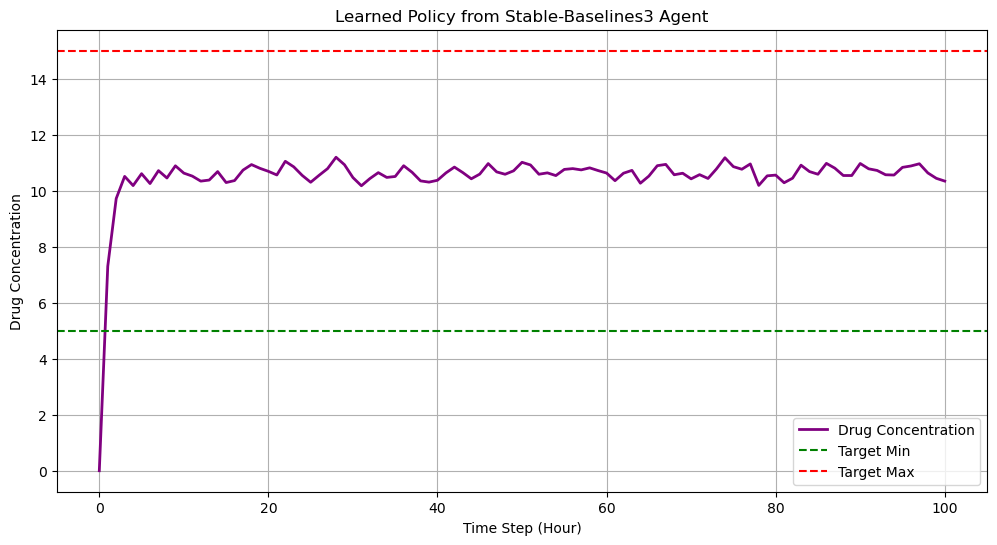

In [4]:
import matplotlib.pyplot as plt
import numpy as np


obs, info = env.reset() 
concentrations = [obs[0]] # Store the history of concentrations


print("--- Running simulation with the trained agent ---")
for _ in range(env.max_steps):
    
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    concentrations.append(obs[0])
    
    if terminated or truncated:
        break

plt.figure(figsize=(12, 6))
plt.plot(concentrations, label='Drug Concentration', color='purple', linewidth=2)
plt.axhline(y=env.target_min, color='green', linestyle='--', label='Target Min')
plt.axhline(y=env.target_max, color='red', linestyle='--', label='Target Max')
plt.title("Learned Policy from Stable-Baselines3 Agent")
plt.xlabel("Time Step (Hour)")
plt.ylabel("Drug Concentration")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
import pickle
import numpy as np
from tqdm import tqdm

env = PatientEnvGymStochastic()
mixed_dataset = []
num_random_steps = 25000
num_expert_steps = 25000

# Collect RANDOM Data
print(f"Collecting {num_random_steps} steps of random data...")
obs, info = env.reset()
for _ in tqdm(range(num_random_steps)):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    mixed_dataset.append((obs, action, reward, next_obs, done))
    obs = next_obs if not done else env.reset()[0]

# Collect EXPERT Data
print(f"\nCollecting {num_expert_steps} steps of expert data...")
obs, info = env.reset()
for _ in tqdm(range(num_expert_steps)):
    action, _ = model.predict(obs, deterministic=True)
    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    mixed_dataset.append((obs, action, reward, next_obs, done))
    obs = next_obs if not done else env.reset()[0]

# Save the new, correct dataset
with open('ppo_collected_dataset2.pkl', 'wb') as f:
    pickle.dump(mixed_dataset, f)

print("\n--- Mixed-quality data collection complete! ---")
print(f"Total experiences collected: {len(mixed_dataset)}")
print("Dataset saved to 'ppo_collected_dataset2.pkl'")

Stochastic Patient Environment created!


100%|█████████████████████████████████████████████████████████████████████████| 25000/25000 [00:01<00:00, 21180.88it/s]


100%|██████████████████████████████████████████████████████████████████████████| 25000/25000 [00:06<00:00, 3758.29it/s]



--- Mixed-quality data collection complete! ---
Total experiences collected: 50000
Dataset saved to 'ppo_collected_dataset2.pkl'


In [61]:
import pickle
import numpy as np
from d3rlpy.dataset import MDPDataset


with open('ppo_collected_dataset2.pkl', 'rb') as f:
    dataset = pickle.load(f)

print(f"Successfully loaded {len(dataset)} experiences.")


# d3rlpy expects data in this format
observations = np.array([experience[0] for experience in dataset])
actions = np.array([experience[1] for experience in dataset])
rewards = np.array([experience[2] for experience in dataset])
terminals = np.array([experience[4] for experience in dataset]) # 'done' flags

# --- 3. Create a d3rlpy-compatible dataset object ---
mdp_dataset = MDPDataset(
    observations=observations,
    actions=actions,
    rewards=rewards,
    terminals=terminals
)

print("Dataset is formatted and ready for d3rlpy!")


Successfully loaded 50000 experiences.
2025-10-25 15:39.21 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) reward_signature=Signature(dtype=[dtype('int64')], shape=[(1,)])
2025-10-25 15:39.21 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2025-10-25 15:39.21 [info     ] Action size has been automatically determined. action_size=1
Dataset is formatted and ready for d3rlpy!


In [62]:
from d3rlpy.algos import CQLConfig
import d3rlpy

# 1. Create the CQL agent 
cql = d3rlpy.algos.CQLConfig(
    conservative_weight=0.01,  # Makes the agent less cautious
    compile_graph=True
).create(device='cpu')

# 2. Start the offline training 
print("Starting offline training with CQL... This may take several minutes.")
cql.fit(
    mdp_dataset,
    n_steps=100  # Let's have the agent study the data 100 times.
)

print("\nOffline training complete!")

Starting offline training with CQL... This may take several minutes.
2025-10-25 15:39.30 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2025-10-25 15:39.30 [debug    ] Building models...            
2025-10-25 15:39.30 [debug    ] Models have been built.       
2025-10-25 15:39.30 [info     ] Directory is created at d3rlpy_logs\CQL_20251025153930
2025-10-25 15:39.30 [info     ] Parameters                     params={'observation_shape': [1], 'action_size': 1, 'config': {'type': 'cql', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': True, 'acto

Stochastic Patient Environment created!
--- Running simulation with the offline-trained CQL agent ---


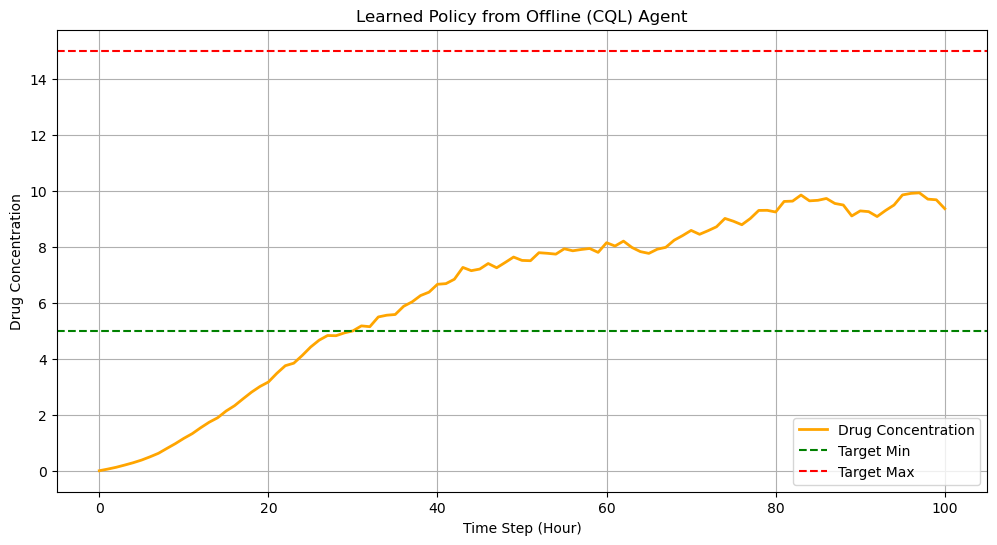

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Initialization ---
# Ensure you have your stochastic environment created in the 'env' variable
# and your trained offline agent in the 'cql' variable.
env = PatientEnvGymStochastic()
obs, info = env.reset() 

concentrations = [obs[0]] # Store the history of concentrations for plotting

# --- 2. Run one full episode with the OFFLINE-trained agent ---
print("--- Running simulation with the offline-trained CQL agent ---")
max_steps = 100 
for _ in range(max_steps):
    
    # a. Get the best action from the CQL agent's brain 🧠
    # d3rlpy's predict method expects a batch, so we add a dimension to our obs
    action= cql.predict(np.expand_dims(obs, axis=0))
    
    # b. Take that action in the environment
    obs, reward, terminated, truncated, info = env.step(action)
    
    # c. Store the result for plotting
    concentrations.append(obs[0])
    
    # d. If the episode ends, stop the loop
    if terminated or truncated:
        break

# --- 3. Plot the results ---
plt.figure(figsize=(12, 6))
plt.plot(concentrations, label='Drug Concentration', color='orange', linewidth=2)
plt.axhline(y=env.target_min, color='green', linestyle='--', label='Target Min')
plt.axhline(y=env.target_max, color='red', linestyle='--', label='Target Max')
plt.title("Learned Policy from Offline (CQL) Agent")
plt.xlabel("Time Step (Hour)")
plt.ylabel("Drug Concentration")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
import numpy as np
from tqdm import tqdm # A library for progress bars

# --- 1. Initialization ---
num_episodes = 100
env = PatientEnvGymStochastic()

# Lists to store the results from each episode
all_total_rewards = []
all_times_in_window = []
all_toxic_events = []

print(f"--- Starting evaluation of CQL agent for {num_episodes} episodes ---")

# --- 2. Evaluation Loop ---
for _ in tqdm(range(num_episodes)):
    obs, info = env.reset()
    
    # Metrics for this single episode
    episode_reward = 0
    steps_in_window = 0
    toxic_events = 0
    
    # Run one full episode
    for step in range(env.max_steps):
        # Predict and execute action
        action_array = cql.predict(np.expand_dims(obs, axis=0))
        obs, reward, terminated, truncated, info = env.step(action_array)
        
        # Update metrics
        episode_reward += reward
        if env.target_min <= env.current_concentration <= env.target_max:
            steps_in_window += 1
        if env.current_concentration > env.target_max:
            toxic_events += 1
        
        if terminated or truncated:
            break
            
    # After the episode, calculate and store the final metrics
    percent_in_window = (steps_in_window / env.max_steps) * 100
    all_total_rewards.append(episode_reward)
    all_times_in_window.append(percent_in_window)
    all_toxic_events.append(toxic_events)

# --- 3. Calculate and Print Final Statistics ---
mean_reward = np.mean(all_total_rewards)
std_reward = np.std(all_total_rewards)

mean_time_in_window = np.mean(all_times_in_window)
std_time_in_window = np.std(all_times_in_window)

mean_toxic_events = np.mean(all_toxic_events)
std_toxic_events = np.std(all_toxic_events)

print("\n--- CQL Agent Evaluation Results ---")
print(f"Average Total Reward:     {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Time in Therapeutic Window: {mean_time_in_window:.2f}% ± {std_time_in_window:.2f}%")
print(f"Average Toxic Events:     {mean_toxic_events:.2f} ± {std_toxic_events:.2f}")

Stochastic Patient Environment created!
--- Starting evaluation of CQL agent for 100 episodes ---


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 61.36it/s]



--- CQL Agent Evaluation Results ---
Average Total Reward:     45.30 ± 2.10
Time in Therapeutic Window: 72.65% ± 1.05%
Average Toxic Events:     0.00 ± 0.00


In [65]:
import numpy as np
from tqdm import tqdm

# --- 1. Initialization ---
num_episodes = 100
# Ensure you are using the final environment with the shaped reward
env = PatientEnvGymStochastic()
model = PPO.load(ppo_path, env)

# Lists to store the results
all_total_rewards = []
all_times_in_window = []
all_toxic_events = []

print(f"--- Starting evaluation of EXPERT PPO agent for {num_episodes} episodes ---")

# --- 2. Evaluation Loop ---
for _ in tqdm(range(num_episodes)):
    obs, info = env.reset()
    episode_reward = 0
    steps_in_window = 0
    toxic_events = 0
    
    for step in range(env.max_steps):
        # Use the PPO model to predict the action
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        # Update metrics
        episode_reward += reward
        if env.target_min <= env.current_concentration <= env.target_max:
            steps_in_window += 1
        if env.current_concentration > env.target_max:
            toxic_events += 1
        
        if terminated or truncated:
            break
            
    percent_in_window = (steps_in_window / env.max_steps) * 100
    all_total_rewards.append(episode_reward)
    all_times_in_window.append(percent_in_window)
    all_toxic_events.append(toxic_events)

# --- 3. Calculate and Print Final Statistics ---
mean_reward = np.mean(all_total_rewards)
std_reward = np.std(all_total_rewards)
mean_time_in_window = np.mean(all_times_in_window)
std_time_in_window = np.std(all_times_in_window)
mean_toxic_events = np.mean(all_toxic_events)
std_toxic_events = np.std(all_toxic_events)

print("\n--- EXPERT PPO Agent Evaluation Results ---")
print(f"Average Total Reward:     {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Time in Therapeutic Window: {mean_time_in_window:.2f}% ± {std_time_in_window:.2f}%")
print(f"Average Toxic Events:     {mean_toxic_events:.2f} ± {std_toxic_events:.2f}")

Stochastic Patient Environment created!
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--- Starting evaluation of EXPERT PPO agent for 100 episodes ---


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 36.78it/s]



--- EXPERT PPO Agent Evaluation Results ---
Average Total Reward:     100.00 ± 0.00
Time in Therapeutic Window: 100.00% ± 0.00%
Average Toxic Events:     0.00 ± 0.00


In [66]:
import numpy as np
from tqdm import tqdm

# --- 1. Initialization ---
num_episodes = 100
# Use the same shaped reward environment for a fair comparison
env = PatientEnvGymStochastic()

# Lists to store the results
all_total_rewards = []
all_times_in_window = []
all_toxic_events = []

print(f"--- Starting evaluation of NAIVE FIXED policy for {num_episodes} episodes ---")

# --- 2. Evaluation Loop ---
for _ in tqdm(range(num_episodes)):
    obs, info = env.reset()
    episode_reward = 0
    steps_in_window = 0
    toxic_events = 0
    
    for step in range(env.max_steps):
        # === THE NAIVE POLICY LOGIC ===
        action = 0.0 # Default action is 0mg
        if step > 0 and step % 10 == 0:
            action = 15.0 # Give 15mg dose every 10 hours
        # =============================

        obs, reward, terminated, truncated, info = env.step(action)
        
        # Update metrics
        episode_reward += reward
        if env.target_min <= env.current_concentration <= env.target_max:
            steps_in_window += 1
        if env.current_concentration > env.target_max:
            toxic_events += 1
        
        if terminated or truncated:
            break
            
    percent_in_window = (steps_in_window / env.max_steps) * 100
    all_total_rewards.append(episode_reward)
    all_times_in_window.append(percent_in_window)
    all_toxic_events.append(toxic_events)

# --- 3. Calculate and Print Final Statistics ---
mean_reward = np.mean(all_total_rewards)
std_reward = np.std(all_total_rewards)
mean_time_in_window = np.mean(all_times_in_window)
std_time_in_window = np.std(all_times_in_window)
mean_toxic_events = np.mean(all_toxic_events)
std_toxic_events = np.std(all_toxic_events)

print("\n--- NAIVE FIXED Policy Evaluation Results ---")
print(f"Average Total Reward:     {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Time in Therapeutic Window: {mean_time_in_window:.2f}% ± {std_time_in_window:.2f}%")
print(f"Average Toxic Events:     {mean_toxic_events:.2f} ± {std_toxic_events:.2f}")

Stochastic Patient Environment created!
--- Starting evaluation of NAIVE FIXED policy for 100 episodes ---


100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2665.54it/s]



--- NAIVE FIXED Policy Evaluation Results ---
Average Total Reward:     10.88 ± 3.91
Time in Therapeutic Window: 55.44% ± 1.96%
Average Toxic Events:     34.54 ± 1.96


In [68]:
import pickle
import numpy as np


with open('ppo_collected_dataset2.pkl', 'rb') as f:
    freshly_loaded_dataset = pickle.load(f)

print(f"Loaded data type: {type(freshly_loaded_dataset)}")
print(f"Total experiences in loaded file: {len(freshly_loaded_dataset)}")


num_random_steps = 25000
expert_data = freshly_loaded_dataset[num_random_steps:]

print(f"Extracted {len(expert_data)} expert experiences for Behavior Cloning.")


# X is the input (the state/observation)
# y is the output we want to imitate (the expert's action)
X_train = np.array([experience[0] for experience in expert_data])
y_train = np.array([experience[1] for experience in expert_data])

print("Data is ready for training the BC model.")

Loaded data type: <class 'list'>
Total experiences in loaded file: 50000
Extracted 25000 expert experiences for Behavior Cloning.
Data is ready for training the BC model.


In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# --- 1. Build the model architecture ---
# This can be a simple multi-layer perceptron (MLP)
bc_model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='linear') # Output one continuous value (the dosage)
])

# --- 2. Compile the model ---
# We use Mean Squared Error because this is a regression problem.
bc_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("--- Training the Behavior Cloning Model ---")
# --- 3. Train the model ---
bc_model.fit(
    X_train,
    y_train,
    validation_split=0.2, # Use 20% of data for validation
    epochs=50,            # Train for 50 passes over the data
    batch_size=256,
    verbose=1             # Show training progress
)
print("\n--- Behavior Cloning Model Training Complete! ---")

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Training the Behavior Cloning Model ---
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6190 - val_loss: 0.5645
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5120 - val_loss: 0.4444
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3547 - val_loss: 0.2479
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1529 - val_loss: 0.0664
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0268 - val_loss: 0.0046
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 2.2960e-04
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1157e-04 - val_loss: 8.6464e-05
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2249e-04 - val_loss: 8.2147e-05
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1315e-04 - val_loss: 8.9856e-05
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3024e-04 - val_loss: 1.0419e-04
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3487e-04 - val_los

In [71]:
import numpy as np
from tqdm import tqdm

# --- 1. Initialization ---
num_episodes = 100
env = PatientEnvGymStochastic()

# Lists to store the results
all_total_rewards = []
all_times_in_window = []
all_toxic_events = []

print(f"--- Starting evaluation of BEHAVIOR CLONING agent for {num_episodes} episodes ---")

# --- 2. Evaluation Loop ---
for _ in tqdm(range(num_episodes)):
    obs, info = env.reset()
    episode_reward = 0
    steps_in_window = 0
    toxic_events = 0
    
    for step in range(env.max_steps):
        # Use the BC model to predict the action
        # We reshape the observation to have a batch dimension for the model
        action = bc_model.predict(obs.reshape(1, -1), verbose=0)
        obs, reward, terminated, truncated, info = env.step(action)
        
        # Update metrics
        episode_reward += reward
        if env.target_min <= env.current_concentration <= env.target_max:
            steps_in_window += 1
        if env.current_concentration > env.target_max:
            toxic_events += 1
        
        if terminated or truncated:
            break
            
    percent_in_window = (steps_in_window / env.max_steps) * 100
    all_total_rewards.append(episode_reward)
    all_times_in_window.append(percent_in_window)
    all_toxic_events.append(toxic_events)

# --- 3. Calculate and Print Final Statistics ---
mean_reward = np.mean(all_total_rewards)
std_reward = np.std(all_total_rewards)
mean_time_in_window = np.mean(all_times_in_window)
std_time_in_window = np.std(all_times_in_window)
mean_toxic_events = np.mean(all_toxic_events)
std_toxic_events = np.std(all_toxic_events)

print("\n--- BEHAVIOR CLONING Agent Evaluation Results ---")
print(f"Average Total Reward:     {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Time in Therapeutic Window: {mean_time_in_window:.2f}% ± {std_time_in_window:.2f}%")
print(f"Average Toxic Events:     {mean_toxic_events:.2f} ± {std_toxic_events:.2f}")

Stochastic Patient Environment created!
--- Starting evaluation of BEHAVIOR CLONING agent for 100 episodes ---


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [09:04<00:00,  5.45s/it]



--- BEHAVIOR CLONING Agent Evaluation Results ---
Average Total Reward:     100.00 ± 0.00
Time in Therapeutic Window: 100.00% ± 0.00%
Average Toxic Events:     0.00 ± 0.00


Stochastic Patient Environment created!
--- Running simulation with the Behavior Cloning agent ---


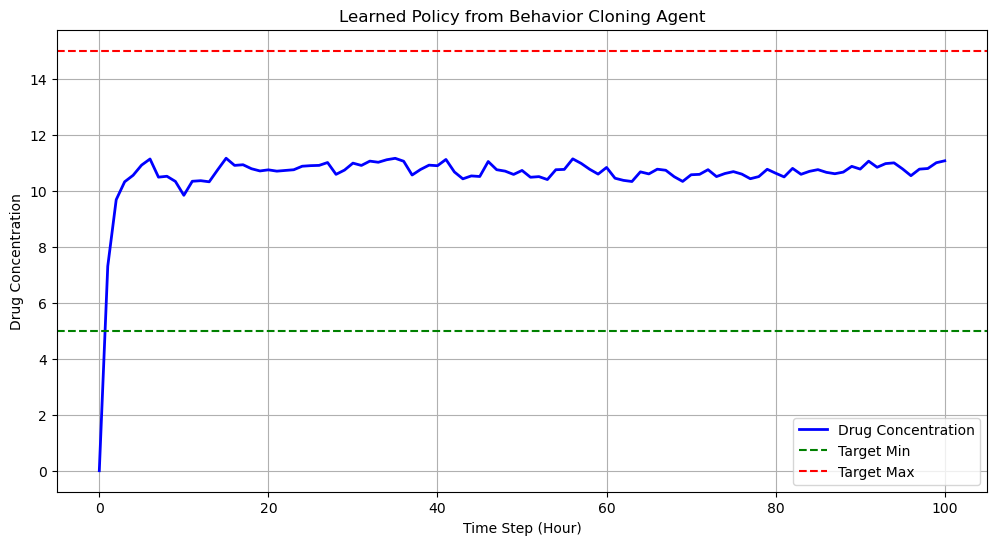

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Initialization ---
# Ensure you are using your final, robust environment class
env = PatientEnvGymStochastic() 
obs, info = env.reset() 

# List to store the history of concentrations for plotting
concentrations = [obs[0]] 

print("--- Running simulation with the Behavior Cloning agent ---")

# --- 2. Run one full episode ---
for _ in range(env.max_steps):
    
    # a. Get the best action from the Behavior Cloning model 🧠
    # We reshape the observation to have a batch dimension (e.g., [[value]]) for the model.
    action = bc_model.predict(obs.reshape(1, -1), verbose=0)
    
    # b. Take that action in the environment
    obs, reward, terminated, truncated, info = env.step(action)
    
    # c. Store the result for plotting
    concentrations.append(obs[0])
    
    # d. If the episode ends, stop the loop
    if terminated or truncated:
        break

# --- 3. Plot the results ---
plt.figure(figsize=(12, 6))
plt.plot(concentrations, label='Drug Concentration', color='blue', linewidth=2)
plt.axhline(y=env.target_min, color='green', linestyle='--', label='Target Min')
plt.axhline(y=env.target_max, color='red', linestyle='--', label='Target Max')
plt.title("Learned Policy from Behavior Cloning Agent")
plt.xlabel("Time Step (Hour)")
plt.ylabel("Drug Concentration")
plt.legend()
plt.grid(True)
plt.show()